In [1]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import matplotlib.pyplot as pt
from sklearn.cluster import KMeans as K
from sklearn.preprocessing import StandardScaler as std
from sklearn.metrics import silhouette_score as sc

# خواندن دیتاست تمیزشده
df = pd.read_csv("cleaned_covid_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Size:", df.shape)

# خواندن فایل‌ به صورت بخش‌های 100 هزار ردیفی
for chunk in pd.read_csv("cleaned_covid_data.csv", chunksize=100000):
    print(len(chunk))

Size: (35041, 10)
35041


In [2]:
# ساخت داده در سطح کشور 

country_data = df.groupby("Country/Region")[
    ["Confirmed", "Deaths", "Recovered", "Active"]
].max()

print(country_data.head())
print("\nتعداد کشورها:", len(country_data))

                Confirmed  Deaths  Recovered  Active
Country/Region                                      
Afghanistan         36263    1269      25198   20311
Albania              4880     144       2745    1991
Algeria             27973    1163      18837    8114
Andorra               907      52        803     504
Angola                950      41        242     667

تعداد کشورها: 187


In [3]:
# انتخاب ویژگی‌های مورد استفاده در Clustering

features = [
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active"
]

X = country_data[features]

print(X.head())

                Confirmed  Deaths  Recovered  Active
Country/Region                                      
Afghanistan         36263    1269      25198   20311
Albania              4880     144       2745    1991
Algeria             27973    1163      18837    8114
Andorra               907      52        803     504
Angola                950      41        242     667


In [4]:
# استانداردسازی داده‌ها

scaler = std()

X_scaled = scaler.fit_transform(X)

print("Scaling is Done")

Scaling is Done


In [5]:
for k in range(2, 9):
    km = K(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    print(k, sc(X, labels))

2 0.9627387467954437
3 0.9468258335289967
4 0.853095705492254
5 0.8452205735824236
6 0.843551479902149
7 0.7215440919043282
8 0.7075129529671506


In [7]:
# اجرای الگوریتم K-Means

kmeans = K(
    n_clusters=4,
    random_state=42,
    n_init=10)

country_data["Cluster"] = kmeans.fit_predict(X_scaled)

print("Clusters:", country_data["Cluster"].nunique())

Clusters: 4


In [8]:
# تعداد کشورهای هر خوشه

cluster_counts = country_data["Cluster"].value_counts().sort_index()

print("Countries/Clusters:")
print(cluster_counts)

Countries/Clusters:
Cluster
0    174
1      1
2      1
3     11
Name: count, dtype: int64


In [9]:
# بررسی ویژگی‌های هر خوشه 

cluster_summary = country_data.groupby("Cluster")[
    features
].mean()

print("Mean:")
print(cluster_summary)

Mean:
            Confirmed         Deaths     Recovered        Active
Cluster                                                         
0        2.604091e+04     790.000000  1.666570e+04  1.186074e+04
1        4.290259e+06  148011.000000  1.325804e+06  2.816444e+06
2        2.442375e+06   87618.000000  1.846641e+06  5.830800e+05
3        4.742531e+05   25569.818182  3.101285e+05  1.605990e+05


In [10]:
# نمایش نمونه کشورها در هر خوشه

for cluster in sorted(country_data["Cluster"].unique()):
    print("\nCluster", cluster)
    
    countries = country_data[
        country_data["Cluster"] == cluster
    ].index.tolist()
    
    print(countries[:10])


Cluster 0
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria']

Cluster 1
['US']

Cluster 2
['Brazil']

Cluster 3
['Chile', 'France', 'India', 'Iran', 'Italy', 'Mexico', 'Peru', 'Russia', 'South Africa', 'Spain']


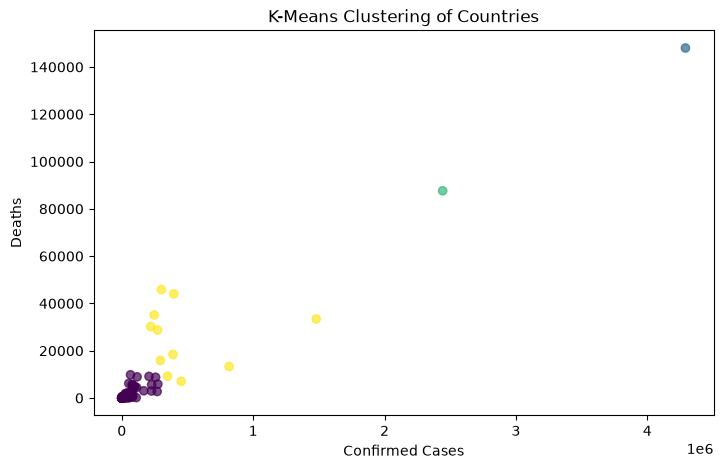

In [11]:
# نمایش خوشه‌ها 

pt.figure(figsize=(8, 5))

pt.scatter(
    country_data["Confirmed"],
    country_data["Deaths"],
    c=country_data["Cluster"],
    alpha=0.7
)

pt.xlabel("Confirmed Cases")
pt.ylabel("Deaths")
pt.title("K-Means Clustering of Countries")

pt.show()

In [12]:
# ذخیره نتیجه Clustering

country_data.to_csv("country_clusters.csv")

print("Saved")

Saved
